In [9]:
import tensorflow as tf

from load_data import load_datasets
from helper_functions import eval_model,display_samples
%matplotlib inline

In [10]:
image_size=512
batch_size=16
dataset_path='130kv2/'

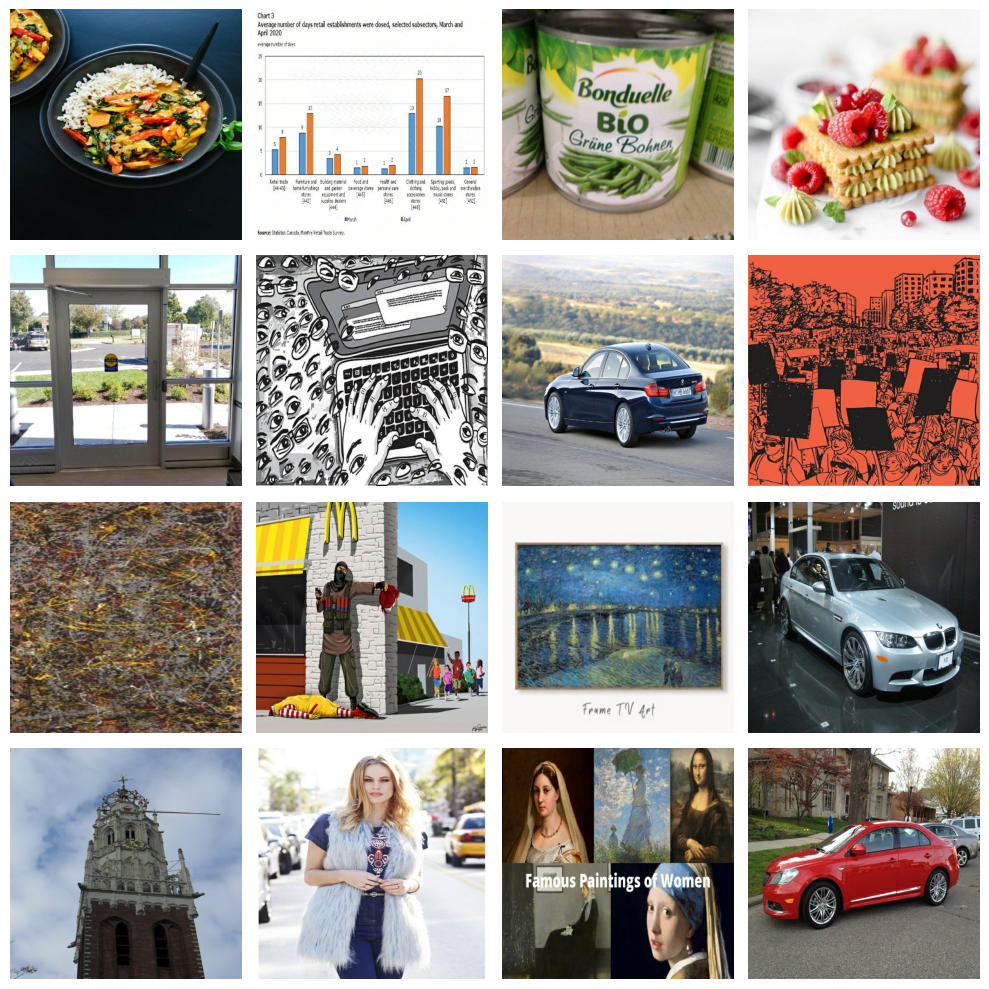

Train dataset: 
tf.Tensor(6160, shape=(), dtype=int64)

Validation dataset: 
tf.Tensor(1320, shape=(), dtype=int64)

Test dataset: 
tf.Tensor(1320, shape=(), dtype=int64)


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>

In [11]:
# load our training, validation and test datasets
train_ds, val_ds, test_ds = load_datasets(dataset_path, image_size, batch_size)

# display 10 samples to make sure they loaded OK
display_samples(train_ds)

# and check how many we have in each dataset
print('Train dataset: ')
print(train_ds.cardinality())
print('\nValidation dataset: ')
print(val_ds.cardinality())
print('\nTest dataset: ')
print(test_ds.cardinality())

# lastly batch them up and cache them
train_ds = train_ds.batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)

train_ds

In [12]:
# add some minor augmentation, avoiding anything which might rescale or otherwise impact perturbations
# see https://keras.io/examples/vision/image_classification_from_scratch/
data_augmentation_layers = tf.keras.Sequential([
    #tf.keras.layers.Normalization(),
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.05),
])

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

In [13]:
def make_model(input_shape, num_classes):
    inputs = tf.keras.Input(shape=input_shape)

    # Entry block
    x = data_augmentation_layers(inputs)
    x = tf.keras.layers.Rescaling(1.0 / 255)(x) # might want to comment this out if we do it in pre
    x = tf.keras.layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)

    previous_block_activation = x  # Set aside residual

    for size in [256, 512]:
        x = tf.keras.layers.Activation("relu")(x)
        x = tf.keras.layers.SeparableConv2D(size, 3, padding="same")(x)
        x = tf.keras.layers.BatchNormalization()(x)

        x = tf.keras.layers.Activation("relu")(x)
        x = tf.keras.layers.SeparableConv2D(size, 3, padding="same")(x)
        x = tf.keras.layers.BatchNormalization()(x)

        x = tf.keras.layers.MaxPooling2D(3, strides=2, padding="same")(x)

        # Project residual
        residual = tf.keras.layers.Conv2D(size, 1, strides=2, padding="same")(
            previous_block_activation
        )
        x = tf.keras.layers.add([x, residual])  # Add back residual
        previous_block_activation = x  # Set aside next residual

    x = tf.keras.layers.SeparableConv2D(1024, 3, padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    if num_classes == 2:
        units = 1
    else:
        units = num_classes

    x = tf.keras.layers.Dropout(0.25)(x)
    # We specify activation=None so as to return logits
    outputs = tf.keras.layers.Dense(units, activation=None)(x)
    return tf.keras.Model(inputs, outputs)

#model = make_model(input_shape=(image_size,image_size) + (3,), num_classes=2)
#tf.keras.utils.plot_model(model, 'models/model.png', show_shapes=True, rankdir='TB')

In [ ]:
from model_construction import model_builder

model = model_builder(input_shape=(image_size,image_size) + (3,), num_classes=2)
#tf.keras.utils.plot_model(model, 'models/model.png', show_shapes=True, rankdir='TB')

In [14]:
epochs = 10

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("models/save_at_{epoch}.keras"),
]
model.compile(
    optimizer=tf.keras.optimizers.Adam(3e-4),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.BinaryAccuracy(name="accuracy")],
)
model_history = model.fit(
    train_ds,
    epochs=epochs,
    callbacks=callbacks,
    validation_data=val_ds,
).history

Epoch 1/10
385/385 [==============================] - 111s 251ms/step - loss: 0.7347 - accuracy: 0.4995 - val_loss: 0.6947 - val_accuracy: 0.5000
Epoch 2/10
385/385 [==============================] - 92s 240ms/step - loss: 0.7172 - accuracy: 0.5094 - val_loss: 0.7063 - val_accuracy: 0.5045
Epoch 3/10
385/385 [==============================] - 92s 240ms/step - loss: 0.6819 - accuracy: 0.5563 - val_loss: 1.0103 - val_accuracy: 0.5000
Epoch 4/10
385/385 [==============================] - 94s 243ms/step - loss: 0.5442 - accuracy: 0.7117 - val_loss: 2.2089 - val_accuracy: 0.5000
Epoch 5/10
385/385 [==============================] - 99s 258ms/step - loss: 0.3801 - accuracy: 0.8258 - val_loss: 1.1369 - val_accuracy: 0.5348
Epoch 6/10
385/385 [==============================] - 94s 245ms/step - loss: 0.3029 - accuracy: 0.8696 - val_loss: 0.7472 - val_accuracy: 0.5394
Epoch 7/10
385/385 [==============================] - 93s 241ms/step - loss: 0.2594 - accuracy: 0.8945 - val_loss: 0.4544 - val_a


initial_model training history


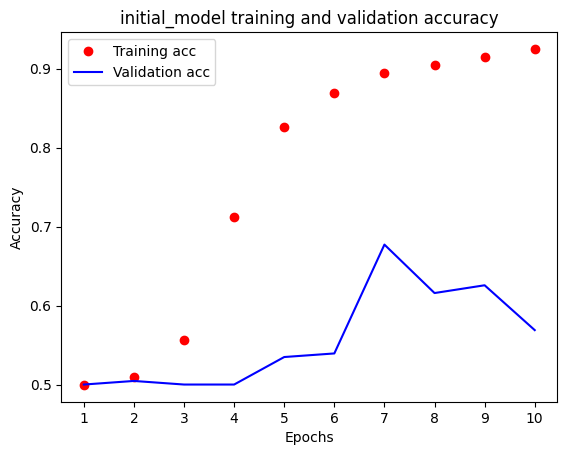

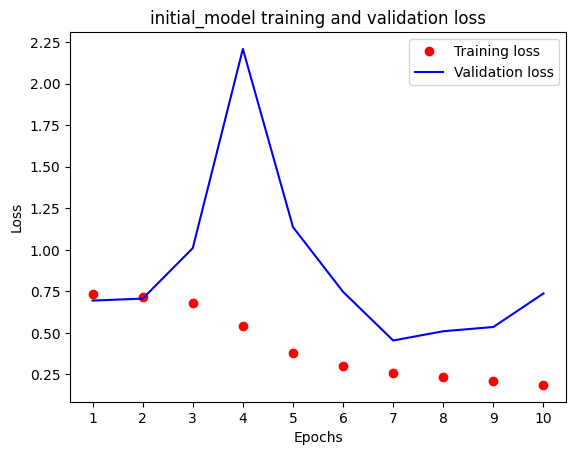

initial_model summary
Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 512, 512, 3)]        0         []                            
                                                                                                  
 sequential_1 (Sequential)   (None, None, None, 3)        0         ['input_2[0][0]']             
                                                                                                  
 rescaling_1 (Rescaling)     (None, 512, 512, 3)          0         ['sequential_1[0][0]']        
                                                                                                  
 conv2d_3 (Conv2D)           (None, 256, 256, 128)        3584      ['rescaling_1[0][0]']         
                                                                      

In [15]:
#model = tf.keras.models.load_model('save_at_3.keras')
eval_results = eval_model('initial_model',model,model_history,val_ds,test_ds)
#model_history